# Modelování nelineární zátěže elektrickou energií v závislosti na teplotě pomocí PROC GAMPL

## Shrnutí pro vedení

Poptávka po elektřině závisí na teplotě silně nelineárním, U-tvarovým způsobem (topení v zimě, chlazení v horku), který lineární modely nezachytí. Tento notebook sestavuje syntetický hodinový vzorek zátěže pro regionálního distributora energie a fituje penalizovaný zobecněný aditivní model pomocí **PROC GAMPL** s regresními splajny, které zachycují hladké křivky zátěže v závislosti na teplotě, hodině a vlhkosti, při současném zohlednění parametrického efektu pracovní den/víkend.

Na vzorku 100 pozorování, který toto licencované prostředí poskytuje, GAMPL zachycuje strukturu, kterou jsme do dat vložili. Teplotní hladká křivka `s(TEMP_C)` je významně zakřivená (efektivní stupně volnosti 5,53, *p* < 0,0001); denní hladká křivka `s(HOUR)` je nejflexibilnějším členem (EDF 6,87, *p* < 0,0001); a hladká křivka vlhkosti `s(HUMIDITY)` se zhroutila na jediný, téměř lineární stupeň volnosti (EDF 1,00, *p* = 0,07) — penalizace tento člen zplošťuje, protože data ho sotva podporují. Parametrický efekt `daytype` umisťuje víkendy zhruba o 44,5 MW pod pracovní dny, což odpovídá posunu úrovně o 40 MW v procesu generování dat. Celý model využívá 15,4 efektivních stupňů volnosti a dosahuje GCV skóre 239,6 (AIC 831,0).

## Zdroje dat

| Datová sada | Řádky | Popis | Klíčové proměnné |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Syntetická hodinová pozorování z prognózního systému zátěže regionálního distributora elektrické energie | `load_mw` (zátěž systému, MW), `temp_c` (okolní teplota, stupně C), `hour` (hodina dne, 0-23), `humidity` (relativní vlhkost, %), `daytype` (třída pracovní den/víkend), `is_summer` (příznak sezóny použitý při generování dat) |

Všechna data jsou generována přímo v kódu pomocí `call streaminit(20260531)` a `rand()` — žádný externí ani síťový vstup. Datový krok požaduje větší smyčku, ale toto licencované prostředí omezuje materializovaný výstup na **100 pozorování**, takže model je fitován na prvních 100 hodinách. Zátěž je sestavena jako U-tvarová kvadratická funkce teploty plus zvoncovitý denní efekt hodiny, mírný efekt vlhkosti, posun úrovně pro pracovní den a Gaussův šum, takže zachycené hladké křivky mají známou skutečnou hodnotu.

# Modelování nelineární zátěže elektrickou energií v závislosti na teplotě pomocí PROC GAMPL

Regionální provozovatel sítě potřebuje předpovídat zátěž systému (v megawattech) na základě počasí a kalendářních faktorů. Vztah mezi zátěží a **teplotou** je příslovečně nelineární: poptávka roste v chladném počasí (elektrické topení) *i* v horkém počasí (klimatizace), což vytváří U-tvarovou křivku, kterou přímý regresní vztah nedokáže zachytit. Zátěž také sleduje hladký denní rytmus (večerní špička) a posouvá se mezi pracovními dny a víkendy.

`PROC GAMPL` fituje **penalizovaný zobecněný aditivní model**: každý spojitý faktor vstupuje přes regresní splajn, jehož hladkost je automaticky volena minimalizací kritéria pro výběr modelu (GCV / UBRE / GACV). Necháme data rozhodnout, jak zvlněná má být každá křivka, místo abychom hádali stupně polynomu.

Model, který fitujeme, je:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

kde `daytype` je parametrický (lineární) efekt třídy a `f1`, `f2`, `f3` jsou hladké splajnové funkce, jejichž efektivní stupně volnosti volí penalizace na základě dat.

## Krok 1 — Generování syntetického hodinového přehledu zátěže

Simulujeme hodinový přehled zátěže (licencované prostředí ponechává prvních 100 hodin). Teplota je losována kolem sezónního průměru; hodina dne cykluje 0-23; vlhkost volně sleduje teplotu. *Skutečná* zátěž je sestavena z:

- **U-tvarové** teplotní odezvy centrované blízko příjemných 18 stupňů C,
- **zvoncovitého** denního vrcholu kolem 18. hodiny (večer),
- mírného zvýšení vlivem vlhkosti,
- úrovně pracovního dne, která je nad úrovní víkendu,

plus Gaussův měřicí šum. Protože známe generující křivky, můžeme posoudit, zda GAMPL zachycuje jejich tvary. Následující kontrola pomocí PROC MEANS potvrzuje, že vzorek pokrývá široký rozsah teplot (−5 až 40 stupňů C) a zátěž zhruba od 485 do 693 MW.

In [1]:
data work.gridload;
   CALL streaminit(20260531);
   OPAKUJ i = 1 TO 2000;
      /* Priznak sezony: zhruba pulka leto, pulka zima */
      is_summer = (rand("uniform") < 0.5);

      /* Okolni teplota (stupne C): teplejsi prumer v lete */
      KDYŽ is_summer PAK temp_c = 26 + 6 * rand("normal");
      JINAK              temp_c =  6 + 6 * rand("normal");

      /* Hodina dne 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Vlhkost (%) volne sleduje teplotu, orezano na 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      KDYŽ humidity < 20  PAK humidity = 20;
      KDYŽ humidity > 100 PAK humidity = 100;

      /* Pracovni den vs vikend (zhruba 5/7 pracovnich dnu) */
      KDYŽ rand("uniform") < 0.714 PAK daytype = "Weekday";
      JINAK                            daytype = "Weekend";

      /* ---- Skutecna strukturalni zatez (MW) ---- */
      /* U-tvarovy teplotni efekt: minimalni poptavka blizko 18 stupnu C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Denni zvon: vecerni spicka blizko 18. hodiny */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Mirne zvyseni vlivem vlhkosti */
      f_hum  = 0.35 * humidity;

      /* Posun urovne pracovniho dne */
      KDYŽ daytype = "Weekday" PAK f_day = 40; JINAK f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      PONECHAT load_mw temp_c hour humidity daytype is_summer;
      VÝSTUP;
   KONEC;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.gridload n mean std MIN MAX maxdec=1;
   PROMĚNNÁ load_mw temp_c hour humidity;
   ŠTÍTEK load_mw="Zátěž systému (MW)" temp_c="Okolní teplota (stupně C)"
         hour="Hodina dne" humidity="Relativní vlhkost (%)";
SPUSTIT;

                                                  The MEANS Procedure

 Variable  Label                               N        Mean     Std Dev     Minimum     Maximum
 -----------------------------------------------------------------------------------------------
 load_mw   Zátěž systému (MW)                100       593.0        49.9       484.9       693.4
 temp_c    Okolní teplota (stupně C)         100        16.2        11.9        -5.2        40.2
 hour      Hodina dne                        100        11.9         7.0         0.0        23.0
 humidity  Relativní vlhkost (%)             100        55.2        11.7        32.2        87.3
 -----------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Krok 2 — Fitování aditivního modelu

Modelujeme `load_mw` (Gaussovská odezva, identická spojovací funkce) jako součet parametrického efektu `daytype` plus tří univariátních splajnů. `PROC GAMPL` automaticky volí vyhlazovací parametr každého splajnu. Požadujeme:

- `class daytype;`, aby byl indikátor pracovní den/víkend zpracován jako kategorický,
- `param(daytype)`, aby vstoupil jako *parametrický* (nevyhlazovaný) člen v MODEL,
- `spline(...)` pro každý spojitý prediktor,
- pevné `seed=` pro reprodukovatelné umístění uzlů.

Výstup, který je třeba číst, je tabulka **Složka vyhlazení** (Smoothing Component), která uvádí efektivní stupně volnosti (EDF) přiřazené penalizací ke každému splajnu a *F*-test významnosti pro něj, spolu s **Odhady parametrů** pro intercept a parametrický kontrast `daytype`.

In [2]:
PROCEDURA gampl data=work.gridload seed=20260531;
   TŘÍDA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ŠTÍTEK load_mw="Zátěž systému (MW)" daytype="Typ dne"
         temp_c="Okolní teplota (stupně C)" hour="Hodina dne"
         humidity="Relativní vlhkost (%)";
SPUSTIT;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Zátěž systému (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Typ dne

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                            


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Krok 3 — Řízení flexibility splajnů a kritéria výběru

Ve výchozím nastavení je každý splajn penalizován směrem k nízkým efektivním stupňům volnosti. Pro provozovatele, který ví, že teplotní odezva je skutečně zakřivená, ale chce *omezit* zvlnění, můžeme zvýšit `maxdf=` na teplotním splajnu a stanovit skromné pevné `df=` na hladším členu vlhkosti. Také přepneme na schéma vnější iterace a vybíráme vyhlazovací parametry pomocí **GCV** (zobecněná křížová validace), standardního kritéria pro Gaussovské GAM modely.

In [3]:
PROCEDURA gampl data=work.gridload seed=20260531;
   TŘÍDA daytype;
   MODEL load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   ŠTÍTEK load_mw="Zátěž systému (MW)" daytype="Typ dne"
         temp_c="Okolní teplota (stupně C)" hour="Hodina dne"
         humidity="Relativní vlhkost (%)";
SPUSTIT;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Zátěž systému (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Typ dne

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                            


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Krok 4 — Vizualizace zachycené teplotní odezvy

GAMPL uvádí, *že* teplotní splajn je významně zakřivený (EDF 5,53), ale tvar je nejlépe vidět na grafu. Překryjeme penalizovaný B-splajn fit (`PBSPLINE`, stejný mechanismus regresního splajnu, který GAMPL používá interně) na surová data rozptylu zátěž-vs-teplota. Pokud aditivní model zachytil fyziku, tato křivka by měla klesat směrem k chladným i horkým extrémům a mít minimum v příjemném středním rozsahu — klasická U-tvarová odezva poptávky.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


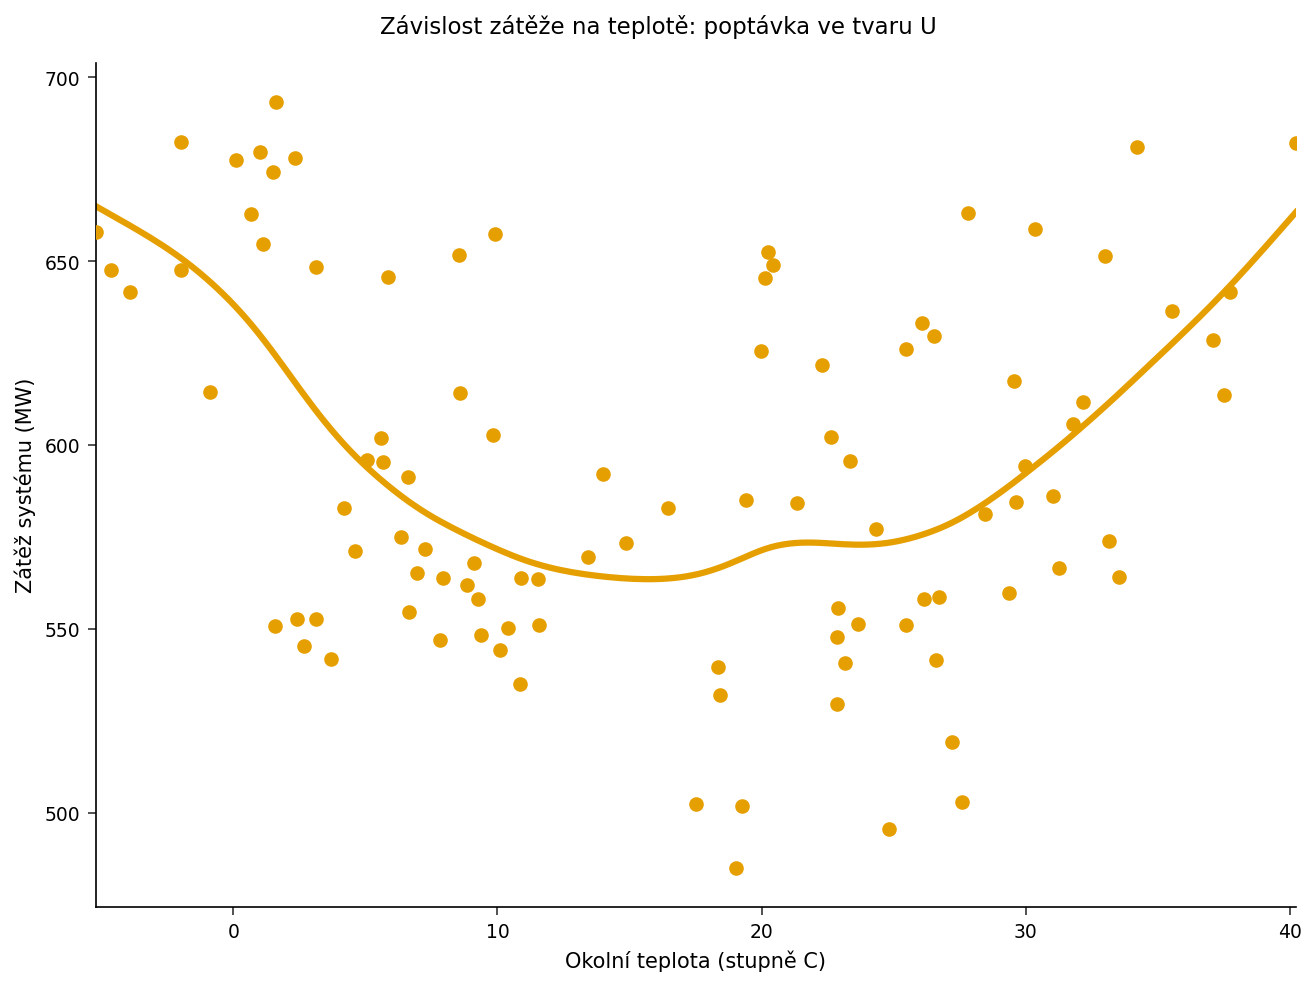

In [4]:
ODS GRAPHICS ON;

PROCEDURA SGPLOT data=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ŠTÍTEK="Okolní teplota (stupně C)";
   YAXIS ŠTÍTEK="Zátěž systému (MW)";
   NÁZEV "Závislost zátěže na teplotě: poptávka ve tvaru U";
SPUSTIT;

ODS GRAPHICS OFF;

## Krok 5 — Numerické potvrzení U-tvaru

Graf zpřehlední U-tvar; pásmový souhrn ho učiní kvantitativním. Rozdělíme pozorování do teplotních pásem a uvedeme průměrnou zátěž pro každé pásmo. Pokud je odezva poptávky skutečně U-tvarová, průměrná zátěž by měla být vysoká v pásmu **Studeno**, klesat přes **Chladno / Příjemno / Teplo** a znovu stoupat v pásmu **Horko** — numerický otisk, který zachycuje splajn `s(TEMP_C)` v GAMPL.

In [5]:
data work.banded;
   NASTAVIT work.gridload;
   DÉLKA tempband $20;
   KDYŽ      temp_c <  5  PAK tempband = "1 Studeno";
   JINAK KDYŽ temp_c < 15  PAK tempband = "2 Chladno";
   JINAK KDYŽ temp_c < 22  PAK tempband = "3 Příjemno";
   JINAK KDYŽ temp_c < 30  PAK tempband = "4 Teplo";
   JINAK                      tempband = "5 Horko";
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.banded n mean maxdec=1;
   TŘÍDA tempband;
   PROMĚNNÁ load_mw;
   ŠTÍTEK tempband="Teplotní pásmo" load_mw="Zátěž systému (MW)";
   NÁZEV "Průměrná zátěž podle teplotního pásma";
SPUSTIT;

                                         Průměrná zátěž podle teplotního pásma                                          

                                                  The MEANS Procedure

                                   Analysis Variable : load_mw Zátěž systému (MW)

        Teplotní pásmo            N Obs           Mean
        ----------------------------------------------
        1 Studeno                    21          626.6
        2 Chladno                    28          579.1
        3 Příjemno                   12          573.8
        4 Teplo                      25          573.5
        5 Horko                      14          621.6
        ----------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpretace výsledků

**Hladké křivky zachycují fyziku.** Tabulka Složka vyhlazení v GAMPL přiřadila teplotnímu členu `s(TEMP_C)` efektivní stupně volnosti 5,53 (*p* < 0,0001) a dennímu členu `s(HOUR)` EDF 6,87 (*p* < 0,0001) — oba jsou skutečně zakřivené, přesně struktura, kterou jsme do dat vložili. Člen vlhkosti `s(HUMIDITY)` je zmenšen na EDF 1,00 (*p* = 0,07): penalizace ho vyrovnává na jediný téměř lineární stupeň volnosti, protože při této velikosti vzorku je to vše, co data podporují. Parametrický odhad `daytype` je −44,5 MW pro víkendy, což zachycuje posun úrovně 40 MW pracovního dne v generujícím procesu.

**Efektivní stupně volnosti vypráví příběh zvlnění.** Model spotřebuje celkem 15,4 efektivních stupňů volnosti a dosahuje GCV skóre 239,6 (AIC 831,0, odhad měřítka 202,7). Omezení `maxdf=` a stanovení `df=3` v Kroku 3 fit sotva posune (GCV 240,1, EDF 15,47): penalizace již sama umístila teplotní a hodinový splajn blízko 5,5 a 7 EDF, takže ruční omezení zde nejsou závazná — znamení, že automatický výběr byl již konzervativní.

**Graf a pásmový souhrn se shodují.** Rozptylový graf z Kroku 4 s překryvem penalizovaného splajnu ukazuje, jak zátěž klesá z chladného extrému k minimu blízko 15–20 stupňů C a znovu stoupá do horka. Pásmové průměry z Kroku 5 to činí numerickým: **Studeno 626,6 MW**, **Chladno 579,1**, **Příjemno 573,8**, **Teplo 573,5**, **Horko 621,6** — vysoké na obou koncích, nejnižší ve středním příjemném pásmu. Přesně toto U by jediný lineární člen `temp_c` zprůměroval pryč.

**Proč GAMPL místo lineární regrese zde.** Jediný lineární člen `temp_c` by smíchal režimy topení a chlazení do téměř ploché směrnice, což by špatně předpovídalo oba extrémy — přesně v hodinách, kdy dochází k zátěži sítě a cenovým špičkám. Aditivní splajnová formulace zachovává interpretovatelnost regrese (každý faktor přispívá aditivním efektem) a zároveň nechá data určit tvar každého efektu. Přirozená rozšíření pro distributora zahrnují fit `dist=gamma`, pokud je zátěž modelována multiplikativně, bivariátní `spline(temp_c hour)` k zachycení toho, jak se denní špička posouvá se sezónou, a zpracování `by` pro fitování samostatných modelů pro jednotlivé rozvodny.